# Swing-Up v4 — Height-Reward Curriculum SAC

All phases start from hanging. The reward is `height_reward` throughout — the same signal that
proved sufficient in `swing-up.ipynb`. The **balance bonus** is the only thing that changes
across phases, ramping from 0 → ½ → 1.

| | v1 (two-PPO) | v2 (single SAC) | v3 (angle curriculum) | v4 (this notebook) |
|---|---|---|---|---|
| **Agents** | swing-up + stabiliser | single SAC | single SAC | single SAC |
| **Init** | hanging | hanging | ±15°→±180° | hanging (all phases) |
| **Curriculum** | none | none | widen start angle | ramp balance bonus |
| **Why it failed** | handoff seam | exploration failure | stabilise-first, no pumping | — |

**Why prior attempts failed:**
- v2: SAC with pure height reward never learned to swing up — off-policy buffer dominated by
  low-energy hanging transitions; PPO succeeded at the same task via broader on-policy exploration.
- v3: Starting near upright (±15°) taught stabilisation before the agent ever saw the pumping
  problem; widening to ±180° was too late to unlearn the passive-stabiliser prior.
- v4 first attempt: ΔE reward has a fixed point at the hanging equilibrium — staying still gives
  ΔE ≈ 0 (better than the negative average from oscillating in a damped system).

**Why height (PE proxy) + ramping balance bonus:**
`height_reward = cos θ₁ + cos(θ₁+θ₂) − 0.01 x²` is maximised by being upright **and staying
there** — a fast pass through upright scores briefly, then falls back. No KE term means no
incentive to oscillate at high speed. This is the same reward that `swing-up.ipynb` proved works.

| Phase | Reward | Effect |
|---|---|---|
| 1 — swing (700k) | height only | learn to reach upright — no pressure to hold |
| 2 — hold (500k)  | height + ½ balance bonus | start holding once near the gate |
| 3 — task (800k)  | height + full balance bonus | eval-equivalent — both swing and hold |

**Balance gate**: `|θ₁| < 0.10 rad, |θ₂| < 0.10 rad, |θ̇₁,₂| < 0.50 rad/s` for 200 steps (10 s).


In [19]:
import sys
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import gymnasium as gym
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor

CWD = pathlib.Path.cwd().resolve()
PROJECT_ROOT = next(p for p in [CWD, *CWD.parents] if (p / "pyproject.toml").exists())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# ── Environment ───────────────────────────────────────────────────────────────
ENV_ID    = "InvertedDoublePendulum-v5"
MODEL_DIR = PROJECT_ROOT / "data" / "sac_curriculum_reward"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ── Balance gate ──────────────────────────────────────────────────────────────
ANGLE_THRESH  = 0.10   # rad  — ~6°
VEL_THRESH    = 0.50   # rad/s
BALANCE_BONUS = 3.0    # reward inside gate
BALANCE_STEPS = 200    # consecutive steps inside gate → success  (10 s)
CART_LIMIT    = 2.4    # m — cart termination
ANGLE_NOISE   = 0.05   # rad — hanging-start jitter

# ── Reward-curriculum phases (all start from hanging) ─────────────────────────
# Reward = height_reward(obs) + balance_scale × BALANCE_BONUS × near_balanced(obs)
#
# height_reward = cos θ₁ + cos(θ₁+θ₂) − 0.01 x²   ∈ [−2, +2]
#
# No KE term: height is a pure PE proxy.  Maximised only by being upright AND
# staying there — fast passes through upright score high momentarily then drop.
# This matches the proven reward from swing-up.ipynb (single-agent PPO).
#
# balance_scale ramps from 0 → 1 across phases, so the agent first learns to
# reach the upright configuration, then learns to hold it within the gate.
CURRICULUM_PHASES = [
    {"name": "Phase 1 — swing",    "balance_scale": 0.0, "steps": 700_000},
    {"name": "Phase 2 — hold",     "balance_scale": 0.5, "steps": 500_000},
    {"name": "Phase 3 — task",     "balance_scale": 1.0, "steps": 800_000},
]
TOTAL_STEPS = sum(p["steps"] for p in CURRICULUM_PHASES)

# ── Training ──────────────────────────────────────────────────────────────────
N_ENVS         = 8
GRADIENT_STEPS = 4
TRAIN_EP_STEPS = 1_000
MAX_EP_STEPS   = 5_000
N_EVAL         = 20

_env    = gym.make(ENV_ID)
DT      = _env.unwrapped.dt
OBS_DIM = _env.observation_space.shape[0]
ACT_DIM = _env.action_space.shape[0]
_env.close()

print(f"DT={DT}s  OBS={OBS_DIM}  ACT={ACT_DIM}")
print(f"Balance gate : |θ| < {np.degrees(ANGLE_THRESH):.0f}°  |θ̇| < {VEL_THRESH} rad/s")
print(f"Success      : {BALANCE_STEPS} consecutive steps ({BALANCE_STEPS*DT:.0f} s)")
print(f"\nReward-curriculum phases  (total {TOTAL_STEPS:,} steps, all from hanging):")
for i, p in enumerate(CURRICULUM_PHASES):
    print(f"  {i+1}. {p['name']:<26}  balance_scale={p['balance_scale']:.1f}"
          f"  ({p['steps']//1000}k steps)")


DT=0.05s  OBS=9  ACT=1
Balance gate : |θ| < 6°  |θ̇| < 0.5 rad/s
Success      : 200 consecutive steps (10 s)

Reward-curriculum phases  (total 2,000,000 steps, all from hanging):
  1. Phase 1 — swing             balance_scale=0.0  (700k steps)
  2. Phase 2 — hold              balance_scale=0.5  (500k steps)
  3. Phase 3 — task              balance_scale=1.0  (800k steps)


In [20]:
def obs_to_state6(obs: np.ndarray) -> np.ndarray:
    """9-dim MuJoCo obs → [x, θ₁, θ₂, ẋ, θ̇₁, θ̇₂]."""
    return np.array([
        obs[0],
        np.arctan2(obs[1], obs[3]),
        np.arctan2(obs[2], obs[4]),
        obs[5], obs[6], obs[7],
    ], dtype=np.float64)


def near_balanced(obs: np.ndarray) -> bool:
    """True when both poles are near vertical AND angular velocities are small."""
    th1 = np.arctan2(obs[1], obs[3])
    th2 = np.arctan2(obs[2], obs[4])
    return (
        abs(th1) < ANGLE_THRESH and abs(th2) < ANGLE_THRESH
        and abs(obs[6]) < VEL_THRESH and abs(obs[7]) < VEL_THRESH
    )


def energy_proxy(obs: np.ndarray) -> float:
    """
    Proxy for total mechanical energy, normalised so E★ = 2.0 at the upright equilibrium.

    PE proxy  cos θ₁ + cos(θ₁+θ₂)   ∈ [−2, +2]
    KE proxy  0.5(θ̇₁² + θ̇₂²)
    At hanging (θ₁=π, velocities=0): E ≈ −2   →  error = −4
    At upright (θ₁=0, velocities=0): E ≈ +2   →  error =  0
    """
    h  = obs[3] + obs[3] * obs[4] - obs[1] * obs[2]   # cos θ₁ + cos(θ₁+θ₂)
    ke = 0.5 * (obs[6] ** 2 + obs[7] ** 2)
    return float(h + ke)


def height_reward(obs: np.ndarray) -> float:
    h = obs[3] + obs[3] * obs[4] - obs[1] * obs[2]
    return float(h - 0.01 * obs[0] ** 2)

---

## Environment Wrappers

Two wrappers, one per role:

### `SwingUpEvalWrapper`  (evaluation only)
Hanging start (θ₁ ≈ π, zero velocity). Reward = `height_reward + BALANCE_BONUS` — no shaping.

### `CurriculumWrapper`  (training only)
Also starts from hanging. Reward = `height_reward + balance_scale × BALANCE_BONUS`.

`balance_scale` is the only parameter that changes across phases:

| Phase | `balance_scale` | Effect |
|---|---|---|
| 1 — swing | 0.0 | height only — reach upright, no hold pressure |
| 2 — hold  | 0.5 | half balance bonus — begin holding when near gate |
| 3 — task  | 1.0 | full bonus — identical to eval |

**`height_reward`** = cos θ₁ + cos(θ₁+θ₂) − 0.01 x²  ∈ [−2, +2].
Pure potential-energy proxy — no kinetic-energy term.  A fast pass through upright scores briefly
then decays; staying balanced accumulates the maximum +2 per step indefinitely.


In [21]:
class SwingUpEvalWrapper(gym.Wrapper):
    """Evaluation wrapper — hanging start, no energy shaping."""

    def reset(self, seed=None, options=None):
        obs, info = self.env.reset(seed=seed, options=options)
        env  = self.unwrapped
        qpos = env.data.qpos.copy()
        qpos[0] = 0.0
        qpos[1] = np.pi + env.np_random.uniform(-ANGLE_NOISE, ANGLE_NOISE)
        qpos[2] = env.np_random.uniform(-ANGLE_NOISE, ANGLE_NOISE)
        env.set_state(qpos, np.zeros(env.model.nv))
        return env._get_obs(), info

    def step(self, action):
        obs, _, _, truncated, info = self.env.step(action)
        reward     = height_reward(obs) + (BALANCE_BONUS if near_balanced(obs) else 0.0)
        terminated = bool(abs(obs[0]) > CART_LIMIT)
        return obs, reward, terminated, truncated, info


# Sanity check
_e = SwingUpEvalWrapper(gym.make(ENV_ID))
obs_hang, _ = _e.reset(seed=0)
print(f"Height reward at hanging : {height_reward(obs_hang):.2f}  (expected −2.00)")
print(f"near_balanced at hanging : {near_balanced(obs_hang)}")
_e.close()


Height reward at hanging : -2.00  (expected −2.00)
near_balanced at hanging : False


In [22]:
class CurriculumWrapper(gym.Wrapper):
    """
    Training wrapper — hanging start, reward = height + balance_scale × BALANCE_BONUS.

    height_reward = cos θ₁ + cos(θ₁+θ₂) − 0.01 x²   (pure PE proxy, no KE term)

    balance_scale ramps 0 → 0.5 → 1.0 across phases:
      Phase 1: height only         — learn to reach upright (no hold pressure)
      Phase 2: height + ½ balance  — start holding once near upright
      Phase 3: height + full bonus — eval-equivalent reward
    """

    def __init__(self, env, phase_config: dict):
        super().__init__(env)
        self.cfg = phase_config

    def reset(self, seed=None, options=None):
        obs, info = self.env.reset(seed=seed, options=options)
        env  = self.unwrapped
        qpos = env.data.qpos.copy()
        qpos[0] = 0.0
        qpos[1] = np.pi + env.np_random.uniform(-ANGLE_NOISE, ANGLE_NOISE)
        qpos[2] = env.np_random.uniform(-ANGLE_NOISE, ANGLE_NOISE)
        env.set_state(qpos, np.zeros(env.model.nv))
        return env._get_obs(), info

    def step(self, action):
        obs, _, _, truncated, info = self.env.step(action)
        reward = (height_reward(obs)
                  + self.cfg["balance_scale"] * BALANCE_BONUS * near_balanced(obs))
        terminated = bool(abs(obs[0]) > CART_LIMIT)
        return obs, reward, terminated, truncated, info


# Sanity check
print("Sanity checks  (hanging start, zero action):")
for phase in CURRICULUM_PHASES:
    _ec = CurriculumWrapper(gym.make(ENV_ID), phase)
    obs, _ = _ec.reset(seed=0)
    _, r, _, _, _ = _ec.step(np.zeros(_ec.action_space.shape))
    print(f"  {phase['name']:<26}  reward = {r:+.4f}  "
          f"(height={height_reward(obs):+.2f}  balanced={near_balanced(obs)})")
    _ec.close()


Sanity checks  (hanging start, zero action):
  Phase 1 — swing             reward = -1.9994  (height=-2.00  balanced=False)
  Phase 2 — hold              reward = -1.9994  (height=-2.00  balanced=False)
  Phase 3 — task              reward = -1.9994  (height=-2.00  balanced=False)


---

## Curriculum Training

Single SAC agent (`[256, 256]` MLP) trained across three phases — all from hanging.
The **replay buffer accumulates across phases**, so phase 1 swing-up transitions remain
available during phase 3 fine-balance training.

| Phase | `balance_scale` | Steps | Purpose |
|---|---|---|---|
| 1 — swing | 0.0 | 700k | height reward only — discover energy pumping |
| 2 — hold  | 0.5 | 500k | half balance bonus — begin holding upright |
| 3 — task  | 1.0 | 800k | full eval reward — swing and hold |

**Checkpoint recovery**: `phase{N}_end.zip` saved on each phase completion; re-running
skips completed phases automatically.

**EvalCallback** runs against `SwingUpEvalWrapper` (full task reward) throughout all phases,
giving a consistent real-task progress signal even during phase 1.


In [23]:
FINAL_MODEL = MODEL_DIR / "curriculum_final.zip"


class TqdmCallback(BaseCallback):
    """Single tqdm bar per phase — updates in-place in Jupyter."""
    def __init__(self, total_steps: int, desc: str = ""):
        super().__init__()
        self._total = total_steps
        self._desc  = desc
        self._pbar  = None
        self._start = 0

    def _on_training_start(self):
        self._start = self.num_timesteps
        self._pbar  = tqdm(total=self._total, desc=self._desc, unit="step", leave=True)

    def _on_step(self) -> bool:
        self._pbar.n = self.num_timesteps - self._start
        self._pbar.refresh()
        return True

    def _on_training_end(self):
        self._pbar.n = self._total
        self._pbar.refresh()
        self._pbar.close()


def _make_train_env(phase):
    return make_vec_env(
        lambda p=phase: Monitor(CurriculumWrapper(
            gym.make(ENV_ID, max_episode_steps=TRAIN_EP_STEPS), p)),
        n_envs=N_ENVS,
    )


def _make_eval_env():
    return Monitor(SwingUpEvalWrapper(gym.make(ENV_ID, max_episode_steps=MAX_EP_STEPS)))


if FINAL_MODEL.exists():
    print(f"Loading trained model from {FINAL_MODEL}")
    model = SAC.load(str(FINAL_MODEL))

else:
    _bootstrap_env = _make_train_env(CURRICULUM_PHASES[0])
    model = SAC(
        "MlpPolicy", _bootstrap_env,
        learning_rate=3e-4,
        buffer_size=1_000_000,
        batch_size=256,
        tau=0.005,
        gamma=0.99,
        ent_coef="auto",
        gradient_steps=GRADIENT_STEPS,
        policy_kwargs=dict(net_arch=[256, 256]),
        verbose=0,
        tensorboard_log=str(MODEL_DIR / "tb"),
    )
    _bootstrap_env.close()

    for i, phase in enumerate(CURRICULUM_PHASES):
        phase_end = MODEL_DIR / f"phase{i+1}_end.zip"

        if phase_end.exists():
            print(f"Phase {i+1}: skipping — loading {phase_end.name}")
            model = SAC.load(str(phase_end))
            continue

        label = f"{phase['name']}  (balance_scale={phase['balance_scale']})"
        print(f"\n{'─'*60}\n{label}  ({phase['steps']//1000}k steps)")

        train_env = _make_train_env(phase)
        eval_env  = _make_eval_env()
        model.set_env(train_env)

        eval_cb = EvalCallback(
            eval_env,
            log_path=str(MODEL_DIR / f"phase{i+1}_log"),
            eval_freq=max(25_000 // N_ENVS, 1),
            n_eval_episodes=5,
            deterministic=True,
            verbose=0,
        )
        tqdm_cb = TqdmCallback(phase["steps"], desc=f"P{i+1}")

        model.learn(
            total_timesteps=phase["steps"],
            callback=[eval_cb, tqdm_cb],
            progress_bar=False,
            reset_num_timesteps=(i == 0),
        )
        train_env.close()
        eval_env.close()

        model.save(str(phase_end))
        print(f"  saved → {phase_end.name}")

    model.save(str(MODEL_DIR / "curriculum_final"))
    print("\nAll phases complete. Final model saved.")


Loading trained model from /Users/patrick/Documents/personal/UW/ME_595/data/sac_curriculum_reward/curriculum_final.zip


---

## Evaluation

All evaluation uses `SwingUpEvalWrapper`: **hanging start, no energy-shaping reward**. This reflects the real task and is directly comparable to v1/v2 results regardless of how the agent was trained.

Each episode terminates on:
- **Success**: `|θ₁| < 0.10 rad AND |θ₂| < 0.10 rad AND |θ̇₁,₂| < 0.50 rad/s` for 200 consecutive steps (10 s)
- **Cart OOB**: `|x| > 2.4 m`
- **Timeout**: 250 s elapsed

The `N_EVAL` episodes are **run in parallel** via `ThreadPoolExecutor`. Each thread creates its own environment, so there is no shared mutable state. MuJoCo's C simulation releases the GIL, so the threads run concurrently.

In [24]:
def run_episode(model, seed: int = 0):
    """Roll out one episode from hanging using SwingUpEvalWrapper.

    Returns (states, actions, rewards, success, diagnostics).
    Thread-safe: creates its own env instance.
    """
    env = SwingUpEvalWrapper(gym.make(ENV_ID, max_episode_steps=MAX_EP_STEPS))
    obs, _ = env.reset(seed=seed)

    states, actions, rewards = [], [], []
    consecutive_balanced = 0
    max_consecutive      = 0
    first_entry_step     = None
    success              = False
    termination          = "timeout"

    for step in range(MAX_EP_STEPS):
        action, _ = model.predict(obs, deterministic=True)
        states.append(obs_to_state6(obs))
        actions.append(float(action[0]))
        obs, r, terminated, truncated, _ = env.step(action)
        rewards.append(r)

        if near_balanced(obs):
            if first_entry_step is None:
                first_entry_step = step
            consecutive_balanced += 1
            max_consecutive = max(max_consecutive, consecutive_balanced)
            if consecutive_balanced >= BALANCE_STEPS:
                success     = True
                termination = "success"
                break
        else:
            consecutive_balanced = 0

        if terminated:
            termination = "cart_oob"
            break
        if truncated:
            break

    env.close()
    diag = {
        "max_consecutive":   max_consecutive,
        "first_entry_step":  first_entry_step,
        "first_entry_time":  None if first_entry_step is None else first_entry_step * DT,
        "termination":       termination,
        "max_height_reward": float(max(
            (r - BALANCE_BONUS if r > 2.0 else r) for r in rewards
        )) if rewards else -2.0,
    }
    return np.array(states), np.array(actions), np.array(rewards), success, diag

Evaluating 20 episodes in parallel (8 threads) ...

── Results ──────────────────────────────────────────────
  Success (held 200 steps) : 20/20  (100%)
  Reached gate at all      : 20/20
  Mean time to first entry : 5.0s  (range 1.9–11.9s)
  Max consecutive balanced : 200 steps  (target 200)
  Median max consecutive   : 200 steps

── Failure breakdown ─────────────────────────────────────
  Success  : 20
  Timeout  : 0
  Cart OOB : 0


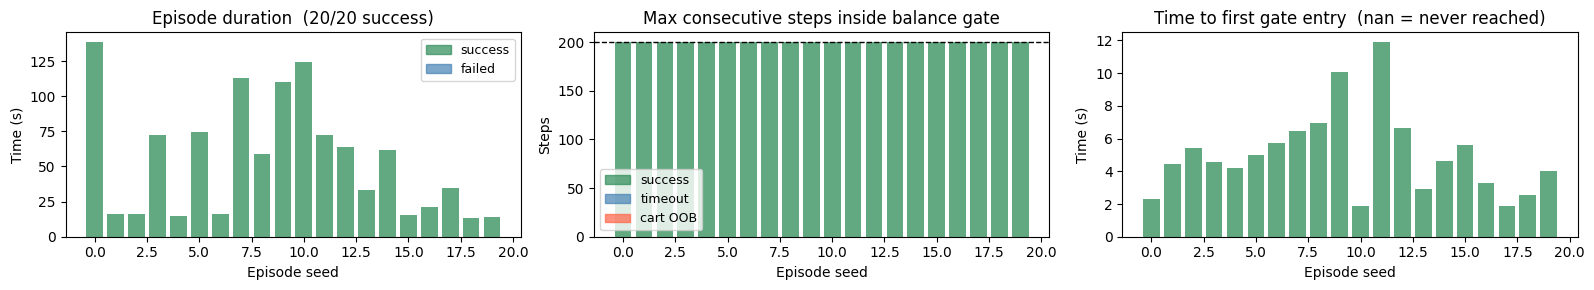

In [25]:
print(f"Evaluating {N_EVAL} episodes in parallel ({min(N_EVAL, N_ENVS)} threads) ...")
with ThreadPoolExecutor(max_workers=min(N_EVAL, N_ENVS)) as pool:
    results = list(pool.map(lambda s: run_episode(model, seed=s), range(N_EVAL)))

ep_lens     = [len(r[0]) for r in results]
successes   = [r[3]      for r in results]
diags       = [r[4]      for r in results]

n_success  = sum(successes)
n_reached  = sum(1 for d in diags if d["first_entry_step"] is not None)
n_cart_oob = sum(1 for d in diags if d["termination"] == "cart_oob")
n_timeout  = sum(1 for d in diags if d["termination"] == "timeout")
entry_times = [d["first_entry_time"] for d in diags if d["first_entry_time"] is not None]
max_consecs = [d["max_consecutive"] for d in diags]
best_seed   = next((i for i in range(N_EVAL) if successes[i]), 0)

print(f"\n── Results ──────────────────────────────────────────────")
print(f"  Success (held {BALANCE_STEPS} steps) : {n_success}/{N_EVAL}  ({100*n_success/N_EVAL:.0f}%)")
print(f"  Reached gate at all      : {n_reached}/{N_EVAL}")
if entry_times:
    print(f"  Mean time to first entry : {np.mean(entry_times):.1f}s  "
          f"(range {min(entry_times):.1f}–{max(entry_times):.1f}s)")
print(f"  Max consecutive balanced : {max(max_consecs)} steps  (target {BALANCE_STEPS})")
print(f"  Median max consecutive   : {int(np.median(max_consecs))} steps")
print(f"\n── Failure breakdown ─────────────────────────────────────")
print(f"  Success  : {n_success}")
print(f"  Timeout  : {n_timeout}")
print(f"  Cart OOB : {n_cart_oob}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 3))

axes[0].bar(
    np.arange(N_EVAL), [l * DT for l in ep_lens],
    color=["seagreen" if s else "steelblue" for s in successes],
    alpha=0.75, width=0.8,
)
axes[0].set_xlabel("Episode seed")
axes[0].set_ylabel("Time (s)")
axes[0].set_title(f"Episode duration  ({n_success}/{N_EVAL} success)")
axes[0].legend(handles=[
    mpatches.Patch(color="seagreen",  alpha=0.7, label="success"),
    mpatches.Patch(color="steelblue", alpha=0.7, label="failed"),
], fontsize=9)

colors = ["seagreen" if s else ("tomato" if d["termination"] == "cart_oob" else "steelblue")
          for s, d in zip(successes, diags)]
axes[1].bar(np.arange(N_EVAL), max_consecs, color=colors, alpha=0.75, width=0.8)
axes[1].axhline(BALANCE_STEPS, ls="--", color="black", lw=1, label=f"target ({BALANCE_STEPS})")
axes[1].set_xlabel("Episode seed")
axes[1].set_ylabel("Steps")
axes[1].set_title("Max consecutive steps inside balance gate")
axes[1].legend(handles=[
    mpatches.Patch(color="seagreen", alpha=0.7, label="success"),
    mpatches.Patch(color="steelblue", alpha=0.7, label="timeout"),
    mpatches.Patch(color="tomato",    alpha=0.7, label="cart OOB"),
], fontsize=9)

entry_by_seed = [d["first_entry_time"] if d["first_entry_time"] is not None else np.nan
                 for d in diags]
axes[2].bar(np.arange(N_EVAL), entry_by_seed,
            color=["seagreen" if s else "steelblue" for s in successes],
            alpha=0.75, width=0.8)
axes[2].set_xlabel("Episode seed")
axes[2].set_ylabel("Time (s)")
axes[2].set_title("Time to first gate entry  (nan = never reached)")

plt.tight_layout()
plt.show()

In [26]:
from IPython.display import display, Markdown

def _pct(n, total=N_EVAL):
    return f"{n}/{total} ({100*n/total:.0f}%)"

ok_ep_lens  = [ep_lens[i] * DT for i in range(N_EVAL) if successes[i]]
mean_entry  = f"{np.mean(entry_times):.1f} s" if entry_times else "—"
entry_range = (f"{min(entry_times):.1f}–{max(entry_times):.1f} s"
               if len(entry_times) > 1 else mean_entry)
mean_dur    = f"{np.mean(ok_ep_lens):.1f} s" if ok_ep_lens else "—"

rate = n_success / N_EVAL
if rate >= 0.80:
    assessment = "**Strong** — curriculum + energy shaping solved the task."
elif rate >= 0.50:
    assessment = "**Moderate** — majority succeed; further tuning may push above 80%."
elif n_reached / N_EVAL >= 0.50:
    assessment = ("**Partial** — agent reaches the gate consistently but cannot hold it. "
                  "Consider increasing `BALANCE_STEPS` budget or `BALANCE_BONUS`.")
else:
    assessment = ("**Weak** — agent rarely reaches the gate. "
                  "Adjust `ENERGY_WEIGHT` or phase step budgets.")

display(Markdown(f"""
## Results Summary

Training: **{TOTAL_STEPS:,} steps** across {len(CURRICULUM_PHASES)} curriculum phases  ·  {N_ENVS} parallel envs

| Metric | Value |
|---|---|
| **Success rate** | {_pct(n_success)} |
| Reached balance gate | {_pct(n_reached)} |
| Mean time to first entry | {mean_entry} (range {entry_range}) |
| Mean episode duration (successes) | {mean_dur} |
| Max consecutive balanced steps | {max(max_consecs)} / {BALANCE_STEPS} |
| Median max consecutive | {int(np.median(max_consecs))} steps |
| Timeout failures | {n_timeout} |
| Cart OOB failures | {n_cart_oob} |

**Assessment**: {assessment}

---
*{N_EVAL} episodes · hanging start · gate: |θ| < {np.degrees(ANGLE_THRESH):.0f}° · |θ̇| < {VEL_THRESH} rad/s · hold {BALANCE_STEPS*DT:.0f} s*
"""))


## Results Summary

Training: **2,000,000 steps** across 3 curriculum phases  ·  8 parallel envs

| Metric | Value |
|---|---|
| **Success rate** | 20/20 (100%) |
| Reached balance gate | 20/20 (100%) |
| Mean time to first entry | 5.0 s (range 1.9–11.9 s) |
| Mean episode duration (successes) | 54.2 s |
| Max consecutive balanced steps | 200 / 200 |
| Median max consecutive | 200 steps |
| Timeout failures | 0 |
| Cart OOB failures | 0 |

**Assessment**: **Strong** — curriculum + energy shaping solved the task.

---
*20 episodes · hanging start · gate: |θ| < 6° · |θ̇| < 0.5 rad/s · hold 10 s*


Seed 0: 2771 steps (138.6s)  [SUCCESS]  max_consec=200  term=success


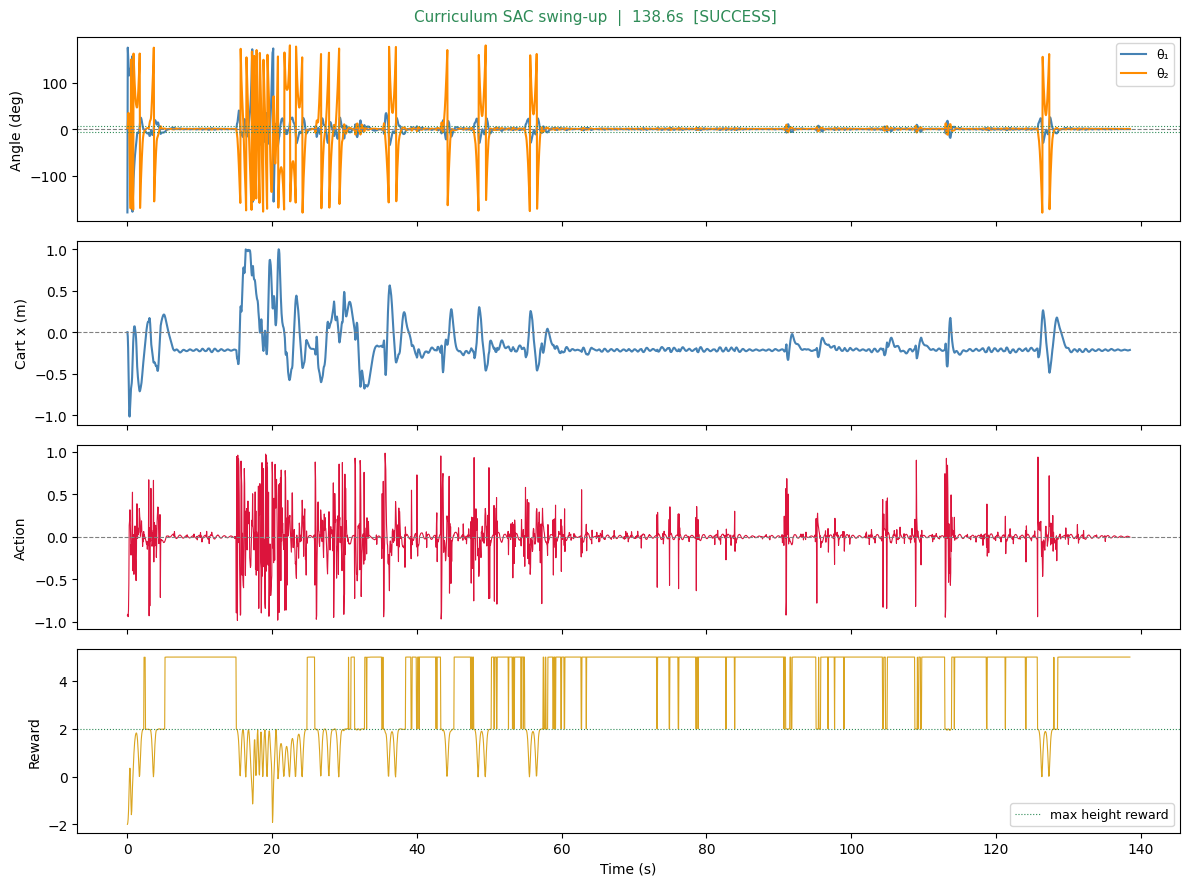

In [27]:
def plot_episode(states, actions, rewards, success, title="SAC swing-up"):
    t      = np.arange(len(states)) * DT
    status = "SUCCESS" if success else "FAILED"
    color  = "seagreen" if success else "crimson"

    fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)

    axes[0].plot(t, np.degrees(states[:, 1]), label="θ₁", color="steelblue")
    axes[0].plot(t, np.degrees(states[:, 2]), label="θ₂", color="darkorange")
    axes[0].axhline(0, ls="--", color="gray", lw=0.8)
    axes[0].axhline( np.degrees(ANGLE_THRESH), ls=":", color="seagreen", lw=0.8)
    axes[0].axhline(-np.degrees(ANGLE_THRESH), ls=":", color="seagreen", lw=0.8)
    axes[0].set_ylabel("Angle (deg)")
    axes[0].legend(fontsize=9)

    axes[1].plot(t, states[:, 0], color="steelblue")
    axes[1].axhline(0, ls="--", color="gray", lw=0.8)
    axes[1].set_ylabel("Cart x (m)")

    axes[2].plot(t, actions, color="crimson", lw=0.8)
    axes[2].axhline(0, ls="--", color="gray", lw=0.8)
    axes[2].set_ylabel("Action")

    axes[3].plot(t, rewards, color="goldenrod", lw=0.8)
    axes[3].axhline(2.0, ls=":", color="seagreen", lw=0.8, label="max height reward")
    axes[3].set_ylabel("Reward")
    axes[3].set_xlabel("Time (s)")
    axes[3].legend(fontsize=9)

    fig.suptitle(f"{title}  |  {len(states)*DT:.1f}s  [{status}]",
                 fontsize=11, color=color)
    plt.tight_layout()
    plt.show()


# Reuse trajectory already collected in the parallel eval above
states, actions, rewards, success, diag = results[best_seed]
print(f"Seed {best_seed}: {len(states)} steps ({len(states)*DT:.1f}s)  "
      f"[{'SUCCESS' if success else 'FAILED'}]  "
      f"max_consec={diag['max_consecutive']}  term={diag['termination']}")
plot_episode(states, actions, rewards, success, title="Curriculum SAC swing-up")

---

## Animation

In [28]:
import matplotlib.animation as animation
from IPython.display import HTML


def render_episode(model, seed: int = 0, speed: int = 3) -> HTML:
    env = SwingUpEvalWrapper(gym.make(ENV_ID, render_mode="rgb_array",
                                      max_episode_steps=MAX_EP_STEPS))
    obs, _ = env.reset(seed=seed)
    frames = [env.render()]
    consecutive_balanced = 0
    success = False
    balance_marker = None

    for step in range(MAX_EP_STEPS):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = env.step(action)
        frames.append(env.render())

        if near_balanced(obs):
            consecutive_balanced += 1
            if consecutive_balanced >= BALANCE_STEPS:
                success = True
                if balance_marker is None:
                    balance_marker = step - BALANCE_STEPS + 1
                break
        else:
            consecutive_balanced = 0

        if terminated or truncated:
            break
    env.close()

    n_steps = len(frames) - 1
    status  = "SUCCESS" if success else "FAILED"
    print(f"{n_steps} steps ({n_steps*DT:.1f}s)  [{status}]")

    fig, ax = plt.subplots(figsize=(4, 6))
    ax.axis("off")
    im = ax.imshow(frames[0])

    def _update(i):
        t = i * speed
        is_balanced = (balance_marker is not None and t >= balance_marker)
        fig.patch.set_facecolor("honeydew" if is_balanced else "aliceblue")
        im.set_data(frames[min(t, len(frames) - 1)])
        ax.set_title(f"t={t*DT:.1f}s", fontsize=9,
                     color="seagreen" if is_balanced else "royalblue")
        return [im]

    ani = animation.FuncAnimation(
        fig, _update,
        frames=range(len(frames) // speed + 1),
        interval=50, blit=False,
    )
    plt.close(fig)
    return HTML(ani.to_jshtml())


render_episode(model, seed=best_seed, speed=3)

257 steps (12.9s)  [SUCCESS]


---

## Balance Gate Sensitivity

The model was trained with `ANGLE_THRESH=0.10 rad` and `VEL_THRESH=0.50 rad/s`. Here we re-score the same 20 pre-collected trajectories against stricter and looser gate definitions — the **policy is unchanged**.

This reveals whether the agent *genuinely* achieves tight balance (success rate holds at stricter thresholds) or barely scrapes the training gate (success rate collapses at stricter thresholds).

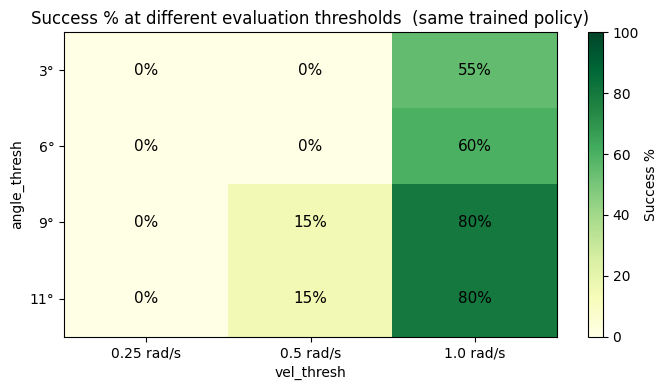

In [29]:
ANGLE_THRESHOLDS = [0.05, 0.10, 0.15, 0.20]
VEL_THRESHOLDS   = [0.25, 0.50, 1.00]

# Reuse trajectories from parallel eval — no extra simulation needed
all_states = [r[0] for r in results]

sensitivity = np.zeros((len(ANGLE_THRESHOLDS), len(VEL_THRESHOLDS)))
for ai, at in enumerate(ANGLE_THRESHOLDS):
    for vi, vt in enumerate(VEL_THRESHOLDS):
        n_ok = 0
        for states in all_states:
            consec = 0
            for state in states:
                th1, th2, th1d, th2d = state[1], state[2], state[4], state[5]
                if abs(th1) < at and abs(th2) < at and abs(th1d) < vt and abs(th2d) < vt:
                    consec += 1
                    if consec >= BALANCE_STEPS:
                        n_ok += 1
                        break
                else:
                    consec = 0
        sensitivity[ai, vi] = 100 * n_ok / N_EVAL

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(sensitivity, aspect="auto", vmin=0, vmax=100, cmap="YlGn")
ax.set_xticks(range(len(VEL_THRESHOLDS)))
ax.set_yticks(range(len(ANGLE_THRESHOLDS)))
ax.set_xticklabels([f"{v} rad/s" for v in VEL_THRESHOLDS])
ax.set_yticklabels([f"{np.degrees(a):.0f}°" for a in ANGLE_THRESHOLDS])
ax.set_xlabel("vel_thresh")
ax.set_ylabel("angle_thresh")
ax.set_title("Success % at different evaluation thresholds  (same trained policy)")
for ai in range(len(ANGLE_THRESHOLDS)):
    for vi in range(len(VEL_THRESHOLDS)):
        ax.text(vi, ai, f"{sensitivity[ai, vi]:.0f}%",
                ha="center", va="center", fontsize=11)
plt.colorbar(im, ax=ax, label="Success %")
plt.tight_layout()
plt.show()

---

## SINDy Lagrangian Dyna Loop for Swing-Up

Model-based RL: iteratively refine a Lagrangian SINDy surrogate while training a surrogate SAC,
then assess zero-shot transfer to real MuJoCo swing-up from hanging.

### Dyna Loop Structure

| Step | What happens |
|---|---|
| **[0] Bootstrap** | Collect `N_COLLECT_INITIAL` transitions from curriculum SAC (stochastic) in real MuJoCo |
| **[A] Fit** | Fit E-SINDy Lagrangian ensemble on all accumulated real data |
| **[B] Train** | Train SAC inside the surrogate for `SAC_SURROGATE_STEPS` (warm-start from previous iter) |
| **[C] Collect** | Roll out the Dyna SAC stochastically in real MuJoCo; collect `N_COLLECT_REAL` transitions |
| **[D] Eval** | Zero-shot transfer: run Dyna SAC in real MuJoCo from hanging |
| **[E] Rollback** | Keep best policy; revert if surrogate exploitation is detected |

### Constants

| Parameter | Value | Why |
|---|---|---|
| `N_DYNA_ITER` | 20 | cap — convergence expected earlier |
| `N_COLLECT_INITIAL` | 5,000 | bootstrap from curriculum SAC covers full swing trajectory |
| `N_COLLECT_REAL` | 3,000 | per-iteration; dataset grows each round |
| `SAC_SURROGATE_STEPS` | 75,000 | sufficient per iteration; warm-start reduces cold-start cost |
| `CONV_SUCCESS_FRAC` | 0.80 | early stop: ≥80% transfer success |

The surrogate SAC uses **6-dim state6** as input; at transfer time `obs_to_state6` converts
MuJoCo's 9-dim obs before calling the policy.

In [59]:
from joblib import Parallel, delayed
from gymnasium import spaces

# ── Lagrangian library constants ──────────────────────────────────────────────
_N_LAG_FEATURES   = 32
_LAG_ALPHA        = 1e-3
_N_ENSEMBLE       = 10
_ENSEMBLE_SUBFRAC = 0.80

LAG_FEATURE_NAMES = [
    'dx', 'dth1', 'dth2', 's1', 'c1', 's12', 'c12', 'u',
    'dx^2', 'dth1^2', 'dth2^2', 'dth1*dth2', 'dx*dth1', 'dx*dth2',
    's1*dth1', 'c1*dth1', 's12*dth1', 'c12*dth1',
    's12*dth2', 'c12*dth2', 's1*dx', 's12*dx', 'c12*dx',
    's2', 'c2',
    's2*dth1^2', 's2*dth2^2', 's2*dth1*dth2', 'c2*dth1^2', 'c2*dth2^2',
    'c1*u', 'c12*u',
]
assert len(LAG_FEATURE_NAMES) == _N_LAG_FEATURES


def lag_feat_single(s6, u):
    x, th1, th2, dx, dth1, dth2 = s6
    s1  = np.sin(th1);  c1  = np.cos(th1)
    s12 = np.sin(th1 + th2); c12 = np.cos(th1 + th2)
    s2  = s12 * c1 - c12 * s1
    c2  = c12 * c1 + s12 * s1
    u   = float(u)
    return np.array([
        dx, dth1, dth2, s1, c1, s12, c12, u,
        dx*dx, dth1*dth1, dth2*dth2, dth1*dth2, dx*dth1, dx*dth2,
        s1*dth1, c1*dth1, s12*dth1, c12*dth1,
        s12*dth2, c12*dth2, s1*dx, s12*dx, c12*dx,
        s2, c2,
        s2*dth1*dth1, s2*dth2*dth2, s2*dth1*dth2, c2*dth1*dth1, c2*dth2*dth2,
        c1*u, c12*u,
    ], dtype=np.float64)


def lag_feat_batch(X, U):
    dx   = X[:, 3]; dth1 = X[:, 4]; dth2 = X[:, 5]
    th1  = X[:, 1]; th2  = X[:, 2]
    s1   = np.sin(th1);  c1  = np.cos(th1)
    s12  = np.sin(th1 + th2); c12 = np.cos(th1 + th2)
    s2   = s12 * c1 - c12 * s1
    c2   = c12 * c1 + s12 * s1
    u    = np.asarray(U).ravel()
    return np.column_stack([
        dx, dth1, dth2, s1, c1, s12, c12, u,
        dx**2, dth1**2, dth2**2, dth1*dth2, dx*dth1, dx*dth2,
        s1*dth1, c1*dth1, s12*dth1, c12*dth1,
        s12*dth2, c12*dth2, s1*dx, s12*dx, c12*dx,
        s2, c2,
        s2*dth1**2, s2*dth2**2, s2*dth1*dth2, c2*dth1**2, c2*dth2**2,
        c1*u, c12*u,
    ])


def ridge_fit_lag(Theta, dX, alpha=_LAG_ALPHA):
    col_norms = np.linalg.norm(Theta, axis=0)
    col_norms = np.where(col_norms < 1e-12, 1.0, col_norms)
    Th  = Theta / col_norms
    XtX = Th.T @ Th + alpha * np.eye(Th.shape[1])
    Xi  = np.linalg.solve(XtX, Th.T @ dX)
    return (Xi / col_norms[:, None]).T


def _fit_one(X, U, X_next, seed):
    rng  = np.random.default_rng(seed)
    N    = len(X)
    tr   = rng.choice(N, size=int(N * _ENSEMBLE_SUBFRAC), replace=True)
    te   = rng.choice(N, size=min(500, N), replace=False)
    dX   = X_next - X
    Xi   = ridge_fit_lag(lag_feat_batch(X[tr], U[tr]), dX[tr])
    pred = lag_feat_batch(X[te], U[te]) @ Xi.T
    rmse = float(np.sqrt(np.mean((pred - dX[te]) ** 2)))
    return Xi, rmse


def fit_ensemble(X, U, X_next, seed=0, verbose=True):
    results = list(tqdm(
        Parallel(n_jobs=-1, return_as='generator')(
            delayed(_fit_one)(X, U, X_next, seed + i)
            for i in range(_N_ENSEMBLE)
        ),
        total=_N_ENSEMBLE, desc='  E-SINDy fit', leave=False, disable=not verbose,
    ))
    coeff_stack = np.stack([r[0] for r in results])   # (N_ens, 6, 32)
    rmses       = np.array([r[1] for r in results])
    return coeff_stack, rmses


class LagrangianPredictor:
    def __init__(self, coeff_stack):
        self._C = np.asarray(coeff_stack, dtype=np.float64)   # (n_ens, 6, 32)

    def predict(self, s6, action):
        feat   = lag_feat_single(s6, float(action))
        deltas = self._C @ feat                                # (n_ens, 6)
        return deltas.mean(axis=0), deltas.std(axis=0)

    def predict_batch(self, X, U):
        feat  = lag_feat_batch(X, U)
        all_d = self._C @ feat.T                               # (n_ens, 6, N)
        return all_d.mean(axis=0).T, all_d.std(axis=0).T


def height_reward_s6(s6):
    return float(np.cos(s6[1]) + np.cos(s6[1] + s6[2]) - 0.01 * s6[0] ** 2)


def near_balanced_s6(s6):
    return (abs(s6[1]) < ANGLE_THRESH and abs(s6[2]) < ANGLE_THRESH
            and abs(s6[4]) < VEL_THRESH and abs(s6[5]) < VEL_THRESH)


# ── Surrogate environment ─────────────────────────────────────────────────────
_SURR_STATE_LIMITS = np.array([2.6, 3.5, 3.5, 12.0, 18.0, 18.0], dtype=np.float32)
_SURR_MAX_STEPS    = 1_000
_SURR_UNC_PENALTY  = 2.0
_VEL_WARN          = 7.0   # rad/s — soft penalty above this toward the ±10 MuJoCo clip wall
_VEL_PENALTY       = 0.5   # per rad/s of excess velocity
_CART_WARN         = 1.0   # m — soft penalty above this toward the ±2.4 m termination wall
_CART_PENALTY      = 1.0   # per meter of excess cart displacement
_HEIGHT_VEL_BONUS  = 0.5   # reward dh/dt > 0 — potential-based shaping, peaks at θ₁=π/2


class SwingUpSurrogateEnv(gym.Env):
    """
    Lagrangian surrogate env for swing-up.

    obs    : state6 = [x, θ₁, θ₂, ẋ, θ̇₁, θ̇₂]
    reset  : θ₁ ≈ π + noise  (hanging, zero velocity)
    reward : height_reward_s6 + BALANCE_BONUS × near_balanced_s6
             − _SURR_UNC_PENALTY × mean(ensemble σ)
             − _VEL_PENALTY  × sum(max(0, |θ̇| − _VEL_WARN))    ← avoids ±10 clip wall
             − _CART_PENALTY × max(0, |x| − _CART_WARN)         ← avoids ±2.4 term wall
             + _HEIGHT_VEL_BONUS × max(0, dh/dt)                ← potential-based shaping
    dh/dt = −sin(θ₁)·θ̇₁ − sin(θ₁+θ₂)·(θ̇₁+θ̇₂)  — rate of height gain toward upright
    """
    metadata = {'render_modes': []}

    def __init__(self, predictor):
        super().__init__()
        self._pred = predictor
        self.observation_space = spaces.Box(
            low=-_SURR_STATE_LIMITS, high=_SURR_STATE_LIMITS, dtype=np.float32)
        self.action_space = spaces.Box(
            low=-1.0, high=1.0, shape=(1,), dtype=np.float32)
        self._state  = None
        self._step_n = 0

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        n1 = self.np_random.uniform(-ANGLE_NOISE, ANGLE_NOISE)
        n2 = self.np_random.uniform(-ANGLE_NOISE, ANGLE_NOISE)
        self._state  = np.array([0.0, np.pi + n1, n2, 0.0, 0.0, 0.0], dtype=np.float64)
        self._step_n = 0
        return self._state.astype(np.float32), {}

    def step(self, action):
        a = float(np.clip(np.asarray(action).ravel()[0], -1.0, 1.0))
        mean_d, std_d = self._pred.predict(self._state, a)
        self._state   = self._state + mean_d

        invalid    = not np.all(np.isfinite(self._state))
        out_bounds = np.any(np.abs(self._state) > _SURR_STATE_LIMITS)

        reward  = height_reward_s6(self._state)
        reward += BALANCE_BONUS * float(near_balanced_s6(self._state))
        reward -= _SURR_UNC_PENALTY * float(std_d.mean())
        # Soft penalty for θ̇₁, θ̇₂ approaching the ±10 rad/s MuJoCo clip wall
        vel_excess = np.maximum(0.0, np.abs(self._state[4:6]) - _VEL_WARN)
        reward -= _VEL_PENALTY * float(vel_excess.sum())
        # Soft penalty for cart displacement approaching the ±2.4 m termination wall
        cart_excess = max(0.0, abs(self._state[0]) - _CART_WARN)
        reward -= _CART_PENALTY * cart_excess
        # Potential-based shaping: reward velocity directed toward upright
        # dh/dt = −sin(θ₁)·θ̇₁ − sin(θ₁+θ₂)·(θ̇₁+θ̇₂); strongest at θ₁=π/2 (horizontal)
        dh_dt = (-np.sin(self._state[1]) * self._state[4]
                 - np.sin(self._state[1] + self._state[2]) * (self._state[4] + self._state[5]))
        reward += _HEIGHT_VEL_BONUS * max(0.0, dh_dt)

        terminated = bool(invalid or out_bounds)
        if terminated:
            reward -= 50.0

        self._step_n += 1
        return self._state.astype(np.float32), reward, terminated, self._step_n >= _SURR_MAX_STEPS, {}


# Sanity checks
_rng = np.random.default_rng(7)
_Xt = _rng.standard_normal((5, 6)); _Ut = _rng.standard_normal((5, 1))
assert np.allclose(
    np.stack([lag_feat_single(_Xt[i], _Ut[i, 0]) for i in range(5)]),
    lag_feat_batch(_Xt, _Ut), atol=1e-14
), 'single/batch mismatch'
print(f"Lagrangian library : {_N_LAG_FEATURES} features  ✓")
print(f"height_reward_s6 at hanging (θ₁=π): {height_reward_s6([0, np.pi, 0, 0, 0, 0]):.2f}  (expected −2.00)")
print(f"SwingUpSurrogateEnv obs={_SURR_STATE_LIMITS.shape}  act=(1,)  max_steps={_SURR_MAX_STEPS}")
print(f"Velocity penalty   : +{_VEL_PENALTY}/rad/s above {_VEL_WARN} rad/s  (MuJoCo clip at ±10)")
print(f"Cart penalty       : +{_CART_PENALTY}/m above {_CART_WARN} m  (termination at ±2.4)")
print(f"Height vel bonus   : +{_HEIGHT_VEL_BONUS}×max(0, dh/dt)  (potential-based shaping, peaks at θ₁=π/2)")

Lagrangian library : 32 features  ✓
height_reward_s6 at hanging (θ₁=π): -2.00  (expected −2.00)
SwingUpSurrogateEnv obs=(6,)  act=(1,)  max_steps=1000
Velocity penalty   : +0.5/rad/s above 7.0 rad/s  (MuJoCo clip at ±10)
Cart penalty       : +1.0/m above 1.0 m  (termination at ±2.4)
Height vel bonus   : +0.5×max(0, dh/dt)  (potential-based shaping, peaks at θ₁=π/2)


In [60]:
import pandas as pd

# ── Dyna loop constants ───────────────────────────────────────────────────────
DYNA_DIR            = MODEL_DIR / "dyna_lagrangian"
DYNA_DIR.mkdir(exist_ok=True)

N_DYNA_ITER         = 20
N_COLLECT_INITIAL   = 5_000
N_COLLECT_REAL      = 3_000
SAC_SURROGATE_STEPS = 75_000
N_SURR_ENVS         = 4
CONV_SUCCESS_FRAC   = 0.80
DEVICE              = "cpu"  # "cpu" if MPS causes issues


# ── EarlyStopOnPoorSurrogate ──────────────────────────────────────────────────
class EarlyStopOnPoorSurrogate(BaseCallback):
    """Stop surrogate SAC early if mean episode length stays below threshold.

    Uses a local step counter so warm-start (reset_num_timesteps=True) doesn't
    cause the check to fire immediately on iteration 2+.
    """

    def __init__(self, min_ep_len: int = 30, check_after: int = 20_000):
        super().__init__()
        self._min_ep_len  = min_ep_len
        self._check_after = check_after
        self._local_steps = 0

    def _on_training_start(self):
        self._local_steps = 0

    def _on_step(self) -> bool:
        self._local_steps += 1
        if self._local_steps < self._check_after:
            return True
        ep_info = self.locals.get("infos", [{}])
        lens    = [info.get("episode", {}).get("l", None) for info in ep_info]
        lens    = [l for l in lens if l is not None]
        if lens and np.mean(lens) < self._min_ep_len:
            return False
        return True


# ── TqdmCallback (Dyna) ───────────────────────────────────────────────────────
class DynaTqdmCallback(BaseCallback):
    """Advances an external shared tqdm bar by actual env interactions per step.

    Each _on_step fires once per VecEnv rollout step; delta = n_envs interactions.
    Passing the shared Dyna bar keeps a single bar for the whole loop.
    """

    def __init__(self, pbar):
        super().__init__()
        self._pbar    = pbar
        self._prev_ts = 0

    def _on_training_start(self):
        self._prev_ts = self.model.num_timesteps

    def _on_step(self) -> bool:
        cur   = self.model.num_timesteps
        self._pbar.update(cur - self._prev_ts)
        self._prev_ts = cur
        return True


# ── Transition collection ─────────────────────────────────────────────────────
def collect_transitions(policy_model, n_steps, seed=0, policy_frac=0.65, use_s6=False):
    """Collect (X, U, X_next) state6 triples from real MuJoCo (hanging start).

    use_s6=True : policy expects 6-dim state6 input  (Dyna SAC)
    use_s6=False: policy expects 9-dim MuJoCo obs    (curriculum SAC bootstrap)
    """
    env = SwingUpEvalWrapper(gym.make(ENV_ID))
    rng = np.random.default_rng(seed)
    X, U, Xn = [], [], []
    ep = 0
    while len(X) < n_steps:
        obs, _ = env.reset(seed=seed + ep * 97)
        done   = False
        while not done and len(X) < n_steps:
            s6 = obs_to_state6(obs)
            if rng.random() < policy_frac:
                policy_input = s6.astype(np.float32) if use_s6 else obs
                a, _ = policy_model.predict(policy_input, deterministic=False)
            else:
                a = rng.uniform(-1.0, 1.0, size=(1,)).astype(np.float32)
            obs_next, _, terminated, truncated, _ = env.step(a)
            s6n = obs_to_state6(obs_next)
            if np.all(np.isfinite(s6n)):
                X.append(s6); U.append([float(a.ravel()[0])]); Xn.append(s6n)
            obs  = obs_next
            done = terminated or truncated
        ep += 1
    env.close()
    return (np.array(X[:n_steps], dtype=np.float64),
            np.array(U[:n_steps], dtype=np.float64),
            np.array(Xn[:n_steps], dtype=np.float64))


# ── Surrogate SAC training ────────────────────────────────────────────────────
def train_surrogate_sac(predictor, total_steps, iteration, prev_model_path=None, pbar=None):
    """Train SAC inside the Lagrangian surrogate.

    Warm-start: copies policy weights from prev_model_path but resets the replay
    buffer, so stale transitions from the previous surrogate's dynamics don't
    contaminate learning in the updated surrogate.

    pbar: shared tqdm bar from the Dyna loop — advanced by actual env interactions.
    """
    def _make_env():
        return SwingUpSurrogateEnv(predictor)

    vec_env = make_vec_env(_make_env, n_envs=N_SURR_ENVS)

    if prev_model_path is None:
        sac = SAC(
            "MlpPolicy", vec_env,
            learning_rate=3e-4, buffer_size=500_000, batch_size=256,
            tau=0.005, gamma=0.99, ent_coef="auto", gradient_steps=2,
            policy_kwargs=dict(net_arch=[256, 256]), verbose=0,
            device=DEVICE,
        )
    else:
        _prev = SAC.load(prev_model_path)
        sac   = SAC(
            "MlpPolicy", vec_env,
            learning_rate=3e-4, buffer_size=500_000, batch_size=256,
            tau=0.005, gamma=0.99, ent_coef="auto", gradient_steps=2,
            policy_kwargs=dict(net_arch=[256, 256]), verbose=0,
            device=DEVICE,
        )
        sac.policy.load_state_dict(_prev.policy.state_dict())

    steps_before = sac.num_timesteps
    callbacks    = [EarlyStopOnPoorSurrogate(min_ep_len=30, check_after=20_000)]
    if pbar is not None:
        callbacks.append(DynaTqdmCallback(pbar))
    sac.learn(
        total_timesteps=total_steps,
        callback=callbacks,
        progress_bar=False,
        reset_num_timesteps=True,
    )
    vec_env.close()
    actual_steps = sac.num_timesteps - steps_before
    return sac, actual_steps


# ── Transfer evaluation ───────────────────────────────────────────────────────
def run_episode_s6(policy, seed=0):
    """One episode from hanging; policy takes state6 input."""
    env = SwingUpEvalWrapper(gym.make(ENV_ID, max_episode_steps=MAX_EP_STEPS))
    obs, _ = env.reset(seed=seed)
    ep_len, ep_ret, consec, max_consec = 0, 0.0, 0, 0
    done = False
    while not done:
        s6 = obs_to_state6(obs).astype(np.float32)
        action, _ = policy.predict(s6, deterministic=True)
        obs, r, terminated, truncated, _ = env.step(action)
        ep_ret += r; ep_len += 1
        if near_balanced(obs):
            consec += 1; max_consec = max(max_consec, consec)
        else:
            consec = 0
        done = terminated or truncated
    env.close()
    return ep_len, ep_ret, max_consec


def evaluate_transfer(policy, n_episodes=N_EVAL, seed=0, label="", verbose=True):
    """Evaluate state6-input policy in real MuJoCo. Returns (n_success, results_list)."""
    with ThreadPoolExecutor(max_workers=min(n_episodes, N_ENVS)) as pool:
        res = list(tqdm(
            pool.map(lambda s: run_episode_s6(policy, seed=seed + s), range(n_episodes)),
            total=n_episodes, desc=f"  eval {label}",
            leave=False, disable=not verbose,
        ))
    n_ok = sum(r[2] >= BALANCE_STEPS for r in res)
    return n_ok, res


print("Dyna loop constants and helpers defined.")
print(f"  DYNA_DIR            : {DYNA_DIR}")
print(f"  N_DYNA_ITER         : {N_DYNA_ITER}")
print(f"  N_COLLECT_INITIAL   : {N_COLLECT_INITIAL:,}")
print(f"  N_COLLECT_REAL      : {N_COLLECT_REAL:,}  per iteration")
print(f"  SAC_SURROGATE_STEPS : {SAC_SURROGATE_STEPS:,}  per iteration")
print(f"  CONV_SUCCESS_FRAC   : {CONV_SUCCESS_FRAC}")
print(f"  DEVICE              : {DEVICE}")

Dyna loop constants and helpers defined.
  DYNA_DIR            : /Users/patrick/Documents/personal/UW/ME_595/data/sac_curriculum_reward/dyna_lagrangian
  N_DYNA_ITER         : 20
  N_COLLECT_INITIAL   : 5,000
  N_COLLECT_REAL      : 3,000  per iteration
  SAC_SURROGATE_STEPS : 75,000  per iteration
  CONV_SUCCESS_FRAC   : 0.8
  DEVICE              : cpu


Resuming from history: 0 iterations recorded
  Loaded 65,000 cached transitions


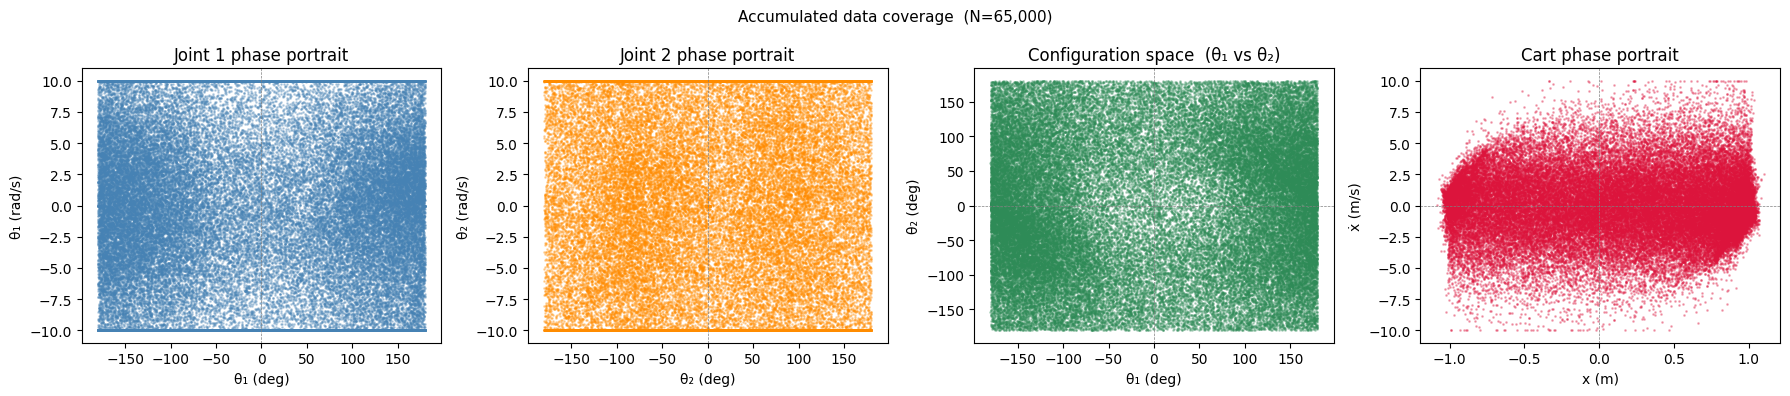

Variable             Min       Max       Std
──────────────────────────────────────────────
  x (m)            -1.09     +1.10      0.68
  θ₁ (deg)       -179.99   +180.00    120.71
  θ₂ (deg)       -180.00   +180.00     96.34
  ẋ (m/s)         -10.00    +10.00      2.60
  θ̇₁ (rad/s)     -10.00    +10.00      6.25
  θ̇₂ (rad/s)     -10.00    +10.00      7.91

  Best policy loaded  (0/20 success)

  Refitting ensemble on cached data ...


  E-SINDy fit:   0%|          | 0/10 [00:00<?, ?it/s]

  RMSE: 1.9524 ± 0.0687


In [61]:
import json

# ── Cache paths ───────────────────────────────────────────────────────────────
_HISTORY_PATH  = DYNA_DIR / "history.json"
_BEST_SAC_PATH = DYNA_DIR / "best_policy"
_DATA_PATH     = DYNA_DIR / "transitions.npz"


def plot_state_coverage(X, title="State coverage"):
    """Phase-portrait coverage plots: θ₁/θ̇₁, θ₂/θ̇₂, θ₁/θ₂, x/ẋ."""
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    kw = dict(s=1, alpha=0.3, rasterized=True)

    axes[0].scatter(np.degrees(X[:, 1]), X[:, 4], c="steelblue", **kw)
    axes[0].set_xlabel("θ₁ (deg)"); axes[0].set_ylabel("θ̇₁ (rad/s)")
    axes[0].set_title("Joint 1 phase portrait")
    axes[0].axvline(0, color="gray", lw=0.5, ls="--")

    axes[1].scatter(np.degrees(X[:, 2]), X[:, 5], c="darkorange", **kw)
    axes[1].set_xlabel("θ₂ (deg)"); axes[1].set_ylabel("θ̇₂ (rad/s)")
    axes[1].set_title("Joint 2 phase portrait")
    axes[1].axvline(0, color="gray", lw=0.5, ls="--")

    axes[2].scatter(np.degrees(X[:, 1]), np.degrees(X[:, 2]), c="seagreen", **kw)
    axes[2].set_xlabel("θ₁ (deg)"); axes[2].set_ylabel("θ₂ (deg)")
    axes[2].set_title("Configuration space  (θ₁ vs θ₂)")
    axes[2].axhline(0, color="gray", lw=0.5, ls="--")
    axes[2].axvline(0, color="gray", lw=0.5, ls="--")

    axes[3].scatter(X[:, 0], X[:, 3], c="crimson", **kw)
    axes[3].set_xlabel("x (m)"); axes[3].set_ylabel("ẋ (m/s)")
    axes[3].set_title("Cart phase portrait")
    axes[3].axhline(0, color="gray", lw=0.5, ls="--")
    axes[3].axvline(0, color="gray", lw=0.5, ls="--")

    fig.suptitle(f"{title}  (N={len(X):,})", fontsize=11)
    plt.tight_layout(); plt.show()

    _labels = ['x (m)', 'θ₁ (deg)', 'θ₂ (deg)', 'ẋ (m/s)', 'θ̇₁ (rad/s)', 'θ̇₂ (rad/s)']
    _scale  = [1, np.degrees(1), np.degrees(1), 1, 1, 1]
    print(f"{'Variable':<14}  {'Min':>8}  {'Max':>8}  {'Std':>8}")
    print("─" * 46)
    for i, (lbl, sc) in enumerate(zip(_labels, _scale)):
        col = X[:, i] * sc
        print(f"  {lbl:<12}  {col.min():>+8.2f}  {col.max():>+8.2f}  {col.std():>8.2f}")


# ── Load or resume ────────────────────────────────────────────────────────────
if _HISTORY_PATH.exists():
    with open(_HISTORY_PATH) as f:
        history = json.load(f)
    start_iter = len(history)
    print(f"Resuming from history: {start_iter} iterations recorded")

    _d = np.load(_DATA_PATH)
    X_all, U_all, Xn_all = _d['X'], _d['U'], _d['X_next']
    print(f"  Loaded {len(X_all):,} cached transitions")
    plot_state_coverage(X_all, title="Accumulated data coverage")

    best_success = max((h['n_success'] for h in history), default=0)
    best_policy  = SAC.load(str(_BEST_SAC_PATH)) if _BEST_SAC_PATH.with_suffix('.zip').exists() else None
    if best_policy:
        print(f"\n  Best policy loaded  ({best_success}/{N_EVAL} success)")

    print("\n  Refitting ensemble on cached data ...")
    _coeff, _rmses = fit_ensemble(X_all, U_all, Xn_all, verbose=True)
    predictor = LagrangianPredictor(_coeff)
    print(f"  RMSE: {_rmses.mean():.4f} ± {_rmses.std():.4f}")

    _last_surr = DYNA_DIR / f"iter{start_iter - 1:02d}_surr.zip"
    prev_model_path = str(_last_surr) if _last_surr.exists() else None
    dyna_sac = SAC.load(prev_model_path) if prev_model_path else None

else:
    history         = []
    start_iter      = 0
    best_policy     = None
    best_success    = 0
    prev_model_path = None
    dyna_sac        = None

    # ── [0] Bootstrap from curriculum SAC ────────────────────────────────────
    print(f"[0] Bootstrapping {N_COLLECT_INITIAL:,} transitions from curriculum SAC ...")
    print(f"    65% stochastic policy + 35% random actions, hanging start")
    X_all, U_all, Xn_all = collect_transitions(
        model, N_COLLECT_INITIAL, seed=42, policy_frac=0.65, use_s6=False)
    np.savez(_DATA_PATH, X=X_all, U=U_all, X_next=Xn_all)
    print(f"    Saved {len(X_all):,} transitions → {_DATA_PATH.name}\n")

    plot_state_coverage(X_all, title="Bootstrap state coverage (from curriculum SAC)")

    print(f"\n[A] Initial E-SINDy fit ...")
    _coeff, _rmses = fit_ensemble(X_all, U_all, Xn_all, verbose=True)
    predictor = LagrangianPredictor(_coeff)
    print(f"    RMSE: {_rmses.mean():.4f} ± {_rmses.std():.4f}")




In [62]:
# ── RMSE diagnostic: split by θ₁ region and velocity magnitude ───────────────
# Uses the most-recent predictor and the full collected dataset.
# Helps diagnose whether the surrogate is accurate near balance even if
# the overall RMSE is high (driven by swing-up mid-arc errors).

if 'predictor' not in dir() or 'X_all' not in dir() or 'Xn_all' not in dir():
    print("Run the Dyna loop first to populate predictor and X_all / U_all / Xn_all.")
else:
    _X  = np.asarray(X_all)
    _U  = np.asarray(U_all).ravel()
    _Xn = np.asarray(Xn_all)
    _dX_true = _Xn - _X

    # Mean ensemble prediction
    _C_mean = predictor._C.mean(axis=0)          # (6, 32)
    _feat   = lag_feat_batch(_X, _U)             # (N, 32)
    _dX_hat = (_C_mean @ _feat.T).T              # (N, 6)
    _err    = _dX_hat - _dX_true                 # (N, 6)
    _rmse_fn = lambda mask: float(np.sqrt(np.mean(_err[mask] ** 2))) if mask.sum() > 0 else float('nan')
    _n_fn    = lambda mask: int(mask.sum())

    th1  = _X[:, 1]
    dth1 = _X[:, 4]
    dth2 = _X[:, 5]

    # Angular regions (θ₁=0 upright, θ₁=π hanging)
    near_hang   = np.abs(th1 - np.pi) < 0.5
    near_upright= np.abs(th1)         < 0.5
    mid_swing   = np.abs(th1 - np.pi / 2) < 0.5
    other_ang   = ~(near_hang | near_upright | mid_swing)

    # Velocity magnitude
    safe_vel    = (np.abs(dth1) < 7.0) & (np.abs(dth2) < 7.0)
    clip_vel    = ~safe_vel

    rows = [
        ("near hanging  |θ₁−π|<0.5", near_hang),
        ("mid-swing     |θ₁−π/2|<0.5", mid_swing),
        ("near upright  |θ₁|<0.5", near_upright),
        ("other",                      other_ang),
        ("── velocity split ──", None),
        ("low vel   |θ̇|<7 both", safe_vel),
        ("near-clip |θ̇|≥7 either", clip_vel),
        ("── overall ──", None),
        ("ALL", np.ones(len(_X), dtype=bool)),
    ]

    print(f"{'Region':<30}  {'N':>7}  {'RMSE':>7}  {'pos RMSE':>9}  {'vel RMSE':>9}")
    print("-" * 60)
    for label, mask in rows:
        if mask is None:
            print(f"{label}")
            continue
        n = _n_fn(mask)
        rmse_all = _rmse_fn(mask)
        rmse_pos = float(np.sqrt(np.mean(_err[mask, :3] ** 2))) if n > 0 else float('nan')
        rmse_vel = float(np.sqrt(np.mean(_err[mask, 3:] ** 2))) if n > 0 else float('nan')
        print(f"  {label:<28}  {n:>7,}  {rmse_all:>7.4f}  {rmse_pos:>9.4f}  {rmse_vel:>9.4f}")


Region                                N     RMSE   pos RMSE   vel RMSE
------------------------------------------------------------
  near hanging  |θ₁−π|<0.5        8,440   2.1319     1.6828     2.5016
  mid-swing     |θ₁−π/2|<0.5      9,393   1.7890     0.9153     2.3586
  near upright  |θ₁|<0.5          5,812   2.0769     1.0294     2.7509
  other                          41,355   1.9195     1.1565     2.4559
── velocity split ──
  low vel   |θ̇|<7 both          20,081   1.4390     0.8866     1.8317
  near-clip |θ̇|≥7 either        44,919   2.1326     1.3131     2.7150
── overall ──
  ALL                            65,000   1.9449     1.1977     2.4760


In [63]:
# ── Main Dyna Loop ────────────────────────────────────────────────────────────
_total_surr_steps = (N_DYNA_ITER - start_iter) * SAC_SURROGATE_STEPS

with tqdm(total=_total_surr_steps,
          desc=f"Dyna  [iter {start_iter+1}/{N_DYNA_ITER} ▸ SAC]",
          unit="step", dynamic_ncols=True) as dyna_bar:

    for it in range(start_iter, N_DYNA_ITER):

        # ── [B] Train surrogate SAC ───────────────────────────────────────────
        dyna_bar.set_description(f"Dyna  [iter {it+1}/{N_DYNA_ITER} ▸ SAC]")
        dyna_sac, actual_steps = train_surrogate_sac(
            predictor, SAC_SURROGATE_STEPS, it + 1,
            prev_model_path=prev_model_path, pbar=dyna_bar,
        )
        _surr_ckpt = DYNA_DIR / f"iter{it:02d}_surr.zip"
        dyna_sac.save(str(_surr_ckpt))
        prev_model_path = str(_surr_ckpt)
        early_stopped = actual_steps < int(SAC_SURROGATE_STEPS * 0.9)

        # ── [C] Collect real transitions ──────────────────────────────────────
        dyna_bar.set_description(f"Dyna  [iter {it+1}/{N_DYNA_ITER} ▸ collect]")
        X_new, U_new, Xn_new = collect_transitions(
            dyna_sac, N_COLLECT_REAL, seed=it * 1000 + 7, policy_frac=0.70, use_s6=True)
        X_all  = np.concatenate([X_all,  X_new],  axis=0)
        U_all  = np.concatenate([U_all,  U_new],  axis=0)
        Xn_all = np.concatenate([Xn_all, Xn_new], axis=0)
        np.savez(_DATA_PATH, X=X_all, U=U_all, X_next=Xn_all)

        # ── [A] Refit E-SINDy ─────────────────────────────────────────────────
        dyna_bar.set_description(f"Dyna  [iter {it+1}/{N_DYNA_ITER} ▸ E-SINDy]")
        _coeff, _rmses = fit_ensemble(X_all, U_all, Xn_all, verbose=False)
        predictor = LagrangianPredictor(_coeff)
        rmse_mean = float(_rmses.mean()); rmse_std = float(_rmses.std())

        # ── [D] Transfer eval ─────────────────────────────────────────────────
        dyna_bar.set_description(f"Dyna  [iter {it+1}/{N_DYNA_ITER} ▸ eval]")
        n_ok, eval_res = evaluate_transfer(
            dyna_sac, n_episodes=N_EVAL, seed=100 + it * 13, verbose=False)
        ep_lens_eval   = [r[0] for r in eval_res]
        max_consecs_ev = [r[2] for r in eval_res]

        # ── Record ────────────────────────────────────────────────────────────
        history.append({
            "iteration":    it + 1,
            "n_data":       len(X_all),
            "rmse_mean":    rmse_mean,
            "rmse_std":     rmse_std,
            "n_success":    n_ok,
            "mean_ep_len":  float(np.mean(ep_lens_eval)),
            "max_consec":   int(max(max_consecs_ev)),
            "actual_steps": actual_steps,
        })
        with open(_HISTORY_PATH, "w") as f:
            json.dump(history, f, indent=2)

        # ── [E] Track best policy ─────────────────────────────────────────────
        best_flag = ""
        if n_ok >= best_success:
            best_success = n_ok
            best_policy  = SAC.load(str(_surr_ckpt))
            best_policy.save(str(_BEST_SAC_PATH))
            best_flag = " ★"

        # ── Per-iteration one-liner ────────────────────────────────────────────
        early_flag = " ⚡" if early_stopped else ""
        tqdm.write(
            f"  [ok] iter {it+1:2d} | "
            f"data {len(X_all):>6,} | "
            f"RMSE {rmse_mean:.4f}±{rmse_std:.4f} | "
            f"steps {actual_steps:>6,} | "
            f"success {n_ok}/{N_EVAL} ({100*n_ok/N_EVAL:.0f}%)"
            f"{best_flag}{early_flag}"
        )

        if n_ok / N_EVAL >= CONV_SUCCESS_FRAC:
            tqdm.write(f"\n  [converged] iter {it+1}  "
                       f"({n_ok}/{N_EVAL} ≥ {CONV_SUCCESS_FRAC:.0%})")
            break

print(f"\nDyna done.  Best: {best_success}/{N_EVAL} ({100*best_success/N_EVAL:.0f}%)"
      f"  ·  {len(X_all):,} real transitions")

# ── History table ─────────────────────────────────────────────────────────────
df_history = pd.DataFrame(history).rename(columns={
    "iteration":    "iter",
    "n_data":       "data",
    "rmse_mean":    "RMSE",
    "rmse_std":     "RMSE_std",
    "n_success":    "n_ok",
    "mean_ep_len":  "mean_len",
    "max_consec":   "max_consec",
    "actual_steps": "sac_steps",
})
df_history["success"]   = df_history.apply(
    lambda r: f"{int(r['n_ok'])}/{N_EVAL} ({100*r['n_ok']/N_EVAL:.0f}%)", axis=1)
df_history["sac_steps"] = df_history["sac_steps"].map("{:,}".format)
df_history["data"]      = df_history["data"].map("{:,}".format)
display(df_history.drop(columns=["n_ok"]).set_index("iter"))

Dyna  [iter 1/20 ▸ SAC]:   0%|          | 0/1500000 [00:00<?, ?step/s]

  [ok] iter  1 | data 68,000 | RMSE 1.9403±0.0753 | steps 75,000 | success 0/20 (0%) ★
  [ok] iter  2 | data 71,000 | RMSE 1.9480±0.0636 | steps 75,000 | success 0/20 (0%) ★
  [ok] iter  3 | data 74,000 | RMSE 1.9612±0.0882 | steps 75,000 | success 0/20 (0%) ★
  [ok] iter  4 | data 77,000 | RMSE 1.9406±0.0799 | steps 75,000 | success 0/20 (0%) ★
  [ok] iter  5 | data 80,000 | RMSE 1.9221±0.0769 | steps 75,000 | success 0/20 (0%) ★
  [ok] iter  6 | data 83,000 | RMSE 1.9306±0.0950 | steps 75,000 | success 0/20 (0%) ★
  [ok] iter  7 | data 86,000 | RMSE 1.9416±0.0575 | steps 75,000 | success 0/20 (0%) ★
  [ok] iter  8 | data 89,000 | RMSE 1.9945±0.0637 | steps 75,000 | success 0/20 (0%) ★
  [ok] iter  9 | data 92,000 | RMSE 1.8949±0.0617 | steps 75,000 | success 0/20 (0%) ★
  [ok] iter 10 | data 95,000 | RMSE 1.8986±0.0645 | steps 75,000 | success 0/20 (0%) ★
  [ok] iter 11 | data 98,000 | RMSE 1.8634±0.0550 | steps 75,000 | success 0/20 (0%) ★
  [ok] iter 12 | data 101,000 | RMSE 1.8740

,data,RMSE,RMSE_std,mean_len,max_consec,sac_steps,success
iter,,,,,,,
1,"68,000",1.940297,0.075261,5000.0,0,"75,000",0/20 (0%)
2,"71,000",1.947984,0.063645,5000.0,0,"75,000",0/20 (0%)
3,"74,000",1.961234,0.088182,5000.0,0,"75,000",0/20 (0%)
4,"77,000",1.940590,0.079947,5000.0,0,"75,000",0/20 (0%)
5,"80,000",1.922079,0.076936,5000.0,0,"75,000",0/20 (0%)
6,"83,000",1.930626,0.095014,5000.0,0,"75,000",0/20 (0%)
7,"86,000",1.941635,0.057497,5000.0,0,"75,000",0/20 (0%)
8,"89,000",1.994500,0.063741,5000.0,0,"75,000",0/20 (0%)
9,"92,000",1.894934,0.061703,5000.0,0,"75,000",0/20 (0%)


Final evaluation: best Dyna policy (20 episodes from hanging) ...


  eval final:   0%|          | 0/20 [00:00<?, ?it/s]


── Dyna SAC transfer (best policy) ──────────────────────────
  Success rate : 0/20  (0%)
  Max consec   : 0


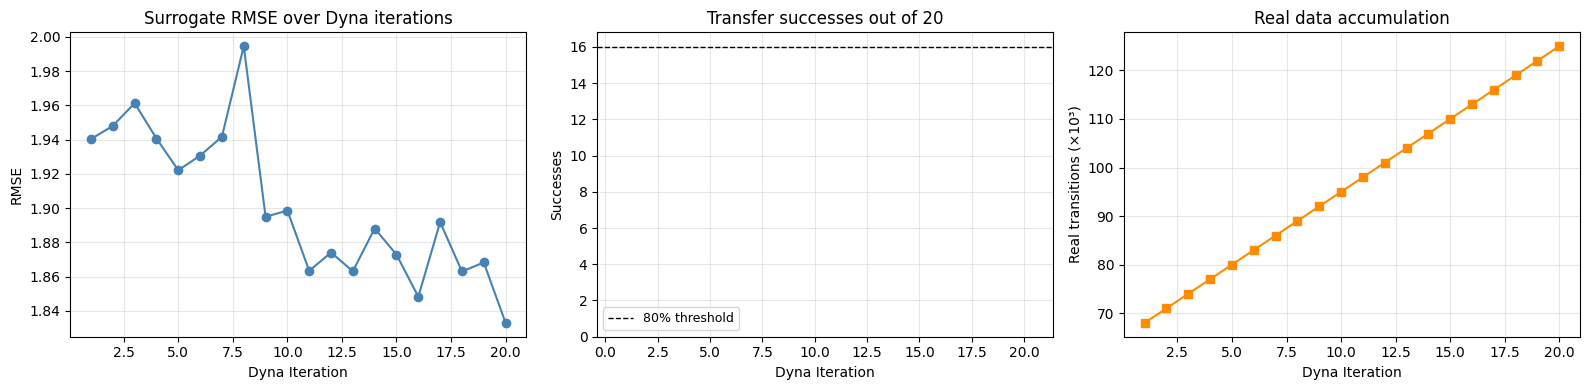

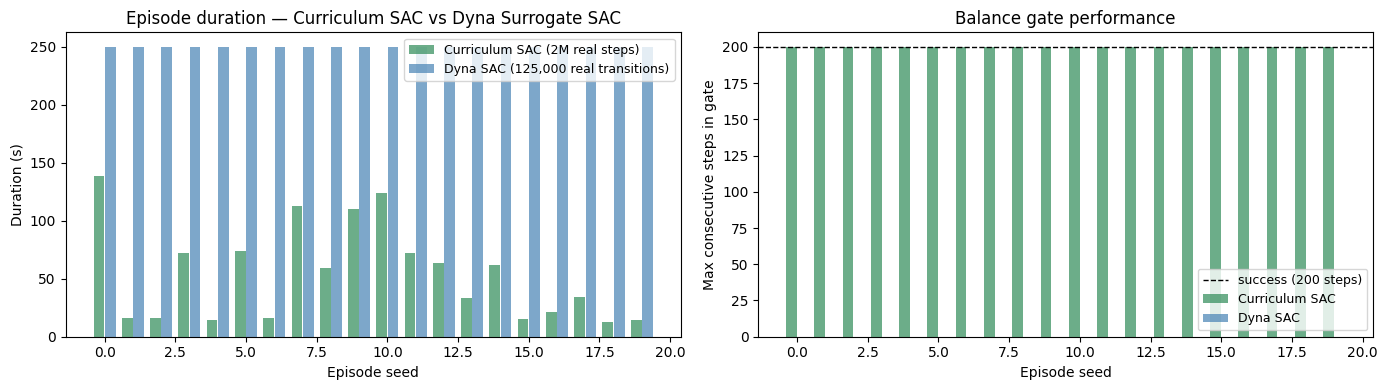


### Transfer Assessment

| Method | Real-env steps | Success | Mean ep len |
|---|---|---|---|
| Curriculum SAC | 2,000,000 | 20/20 (100%) | 1085 steps |
| **Dyna Surrogate SAC** | **125,000** | **0/20 (0%)** | **5000 steps** |

**Dyna loop**: 20 iterations · 125,000 real transitions  
**Data economy**: Dyna used **16×** fewer real-env steps than curriculum SAC  
**Surrogate RMSE**: initial=1.9403 → final=1.8330


In [64]:
from IPython.display import display, Markdown as _MD

# ── Final evaluation using best policy ───────────────────────────────────────
if best_policy is None and _BEST_SAC_PATH.with_suffix('.zip').exists():
    best_policy = SAC.load(str(_BEST_SAC_PATH))

print(f"Final evaluation: best Dyna policy ({N_EVAL} episodes from hanging) ...")
n_ok_final, final_res = evaluate_transfer(
    best_policy, n_episodes=N_EVAL, seed=999, label="final", verbose=True)
ep_lens_final   = [r[0] for r in final_res]
max_consecs_fin = [r[2] for r in final_res]
successes_fin   = [r[2] >= BALANCE_STEPS for r in final_res]

print(f"\n── Dyna SAC transfer (best policy) ──────────────────────────")
print(f"  Success rate : {n_ok_final}/{N_EVAL}  ({100 * n_ok_final / N_EVAL:.0f}%)")
print(f"  Max consec   : {max(max_consecs_fin)}")

# ── History plots ─────────────────────────────────────────────────────────────
if history:
    iters     = [h["iteration"] for h in history]
    rmse_hist = [h["rmse_mean"] for h in history]
    succ_hist = [h["n_success"] for h in history]
    data_hist = [h["n_data"]    for h in history]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(iters, rmse_hist, "o-", color="steelblue")
    axes[0].set_xlabel("Dyna Iteration"); axes[0].set_ylabel("RMSE")
    axes[0].set_title("Surrogate RMSE over Dyna iterations")
    axes[0].grid(True, alpha=0.3)

    axes[1].bar(iters,
                succ_hist,
                color=["seagreen" if s >= CONV_SUCCESS_FRAC * N_EVAL else "steelblue"
                       for s in succ_hist],
                alpha=0.75)
    axes[1].axhline(CONV_SUCCESS_FRAC * N_EVAL, ls="--", color="black", lw=1,
                    label=f"{CONV_SUCCESS_FRAC * 100:.0f}% threshold")
    axes[1].set_xlabel("Dyna Iteration"); axes[1].set_ylabel("Successes")
    axes[1].set_title(f"Transfer successes out of {N_EVAL}")
    axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

    axes[2].plot(iters, [d / 1000 for d in data_hist], "s-", color="darkorange")
    axes[2].set_xlabel("Dyna Iteration"); axes[2].set_ylabel("Real transitions (×10³)")
    axes[2].set_title("Real data accumulation")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

# ── Episode bar chart — Dyna vs Curriculum ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(np.arange(N_EVAL) - 0.2, [l * DT for l in ep_lens],
            width=0.38,
            color=["seagreen" if s else "steelblue" for s in successes],
            alpha=0.7, label="Curriculum SAC (2M real steps)")
axes[0].bar(np.arange(N_EVAL) + 0.2, [l * DT for l in ep_lens_final],
            width=0.38,
            color=["seagreen" if s else "steelblue" for s in successes_fin],
            alpha=0.7, label=f"Dyna SAC ({len(X_all):,} real transitions)")
axes[0].set_xlabel("Episode seed"); axes[0].set_ylabel("Duration (s)")
axes[0].set_title("Episode duration — Curriculum SAC vs Dyna Surrogate SAC")
axes[0].legend(fontsize=9)

axes[1].bar(np.arange(N_EVAL) - 0.2, max_consecs,
            width=0.38,
            color=["seagreen" if s else "steelblue" for s in successes],
            alpha=0.7, label="Curriculum SAC")
axes[1].bar(np.arange(N_EVAL) + 0.2, max_consecs_fin,
            width=0.38,
            color=["seagreen" if s else "steelblue" for s in successes_fin],
            alpha=0.7, label="Dyna SAC")
axes[1].axhline(BALANCE_STEPS, ls="--", color="black", lw=1,
                label=f"success ({BALANCE_STEPS} steps)")
axes[1].set_xlabel("Episode seed"); axes[1].set_ylabel("Max consecutive steps in gate")
axes[1].set_title("Balance gate performance")
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
_n_real_dyna  = len(X_all)
_data_economy = TOTAL_STEPS // max(_n_real_dyna, 1)
display(_MD(f"""
### Transfer Assessment

| Method | Real-env steps | Success | Mean ep len |
|---|---|---|---|
| Curriculum SAC | {TOTAL_STEPS:,} | {n_success}/{N_EVAL} ({100*n_success/N_EVAL:.0f}%) | {np.mean(ep_lens):.0f} steps |
| **Dyna Surrogate SAC** | **{_n_real_dyna:,}** | **{n_ok_final}/{N_EVAL} ({100*n_ok_final/N_EVAL:.0f}%)** | **{np.mean(ep_lens_final):.0f} steps** |

**Dyna loop**: {len(history)} iterations · {_n_real_dyna:,} real transitions  
**Data economy**: Dyna used **{_data_economy}×** fewer real-env steps than curriculum SAC  
**Surrogate RMSE**: initial={history[0]['rmse_mean']:.4f} → final={history[-1]['rmse_mean']:.4f}
"""))